# 05 - Evaluation, Deployment, and Conclusions

**Customer Churn Prediction**, AAI-510, Group 6

This notebook evaluates the selected model in depth, compares it against the alternatives,
discusses how the model would be deployed, and closes with business recommendations tied
back to the original problem statement. We load the saved model and metrics from notebook 04,
so the results here are fully reproducible.


## What each metric means for this project

We report several classification metrics below. The table explains what each one means in the
context of telecom churn, where missing a likely churner (a false negative) costs more than a
false alarm (a false positive).

| Metric | What it means for this project |
| --- | --- |
| Accuracy | Of all customers in the test split, the share the model labels correctly as churn or stay. It is a useful headline number, but with about 33 percent churn it can look high while still missing churners, so we do not rely on it alone for retention decisions. |
| Precision | Of the customers the model flags as likely to churn, the share who actually churn. High precision means a retention campaign wastes little budget on customers who were never going to leave, keeping the cost of discounts and outreach focused on genuine churn risk. |
| Recall | Of the customers who actually churn, the share the model successfully flags. This is our priority metric, because a missed churner is lost revenue. We accept some false alarms to catch more leavers, and we tune the decision threshold below 0.5 to raise recall. |
| F1-Score | The harmonic mean of precision and recall, summarising both in one number. It rewards a model that catches churners (recall) without flooding the retention team with false alarms (precision). We use it to compare models when we want balanced performance rather than favouring one error type. |
| ROC-AUC | The probability that the model scores a random churner higher than a random non-churner, across all thresholds. At about 0.80 our model ranks churn risk well above chance. Because it is threshold-independent, it is our main tool for comparing models before we pick an operating threshold. |
| Confusion Matrix | A two-by-two table of predictions versus reality: churners caught, churners missed (false negatives), false alarms (false positives), and stayers correctly cleared. It makes the costly false negatives visible, letting us see how many likely churners would slip through at a given decision threshold. |
| Classification Report | A scikit-learn summary printing precision, recall, and F1 for both the churn and stay classes, plus support counts. It reports performance per class rather than overall, confirming the model does not earn its scores by simply favouring the larger stay class and neglecting churners. |


In [1]:
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                             roc_auc_score, precision_score, recall_score, f1_score,
                             precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")["Churn"]
best_model = joblib.load("../models/best_model.pkl")
preprocessor = joblib.load("../models/preprocessor.pkl")
with open("../models/metrics.json") as f:
    meta = json.load(f)

best_name = meta["best_model"]
print(f"Loaded best model: {best_name}")
print(f"Test set: {X_test.shape}")

Loaded best model: Logistic Regression
Test set: (20000, 18)


## Model comparison

First we revisit how all candidate models scored on the test set, using the metrics saved by
notebook 04. We emphasize ROC-AUC (overall ranking quality) and Recall (share of real
churners caught).


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.7597,0.6536,0.5850,0.6174,0.8057
XGBoost (tuned),0.7409,0.6042,0.6325,0.6180,0.8051
Voting Ensemble,0.7553,0.6360,0.6119,0.6237,0.8045
Gradient Boosting,0.7459,0.6134,0.6313,0.6222,0.8034
Random Forest (tuned),0.7359,0.5937,0.6431,0.6174,0.8031
"SVM (RBF, subsample)",0.7380,0.5959,0.6511,0.6223,0.8023
Decision Tree,0.7371,0.5966,0.6389,0.6170,0.8020
XGBoost,0.7190,0.5639,0.6719,0.6132,0.8019
Random Forest,0.7391,0.6001,0.6378,0.6184,0.8018


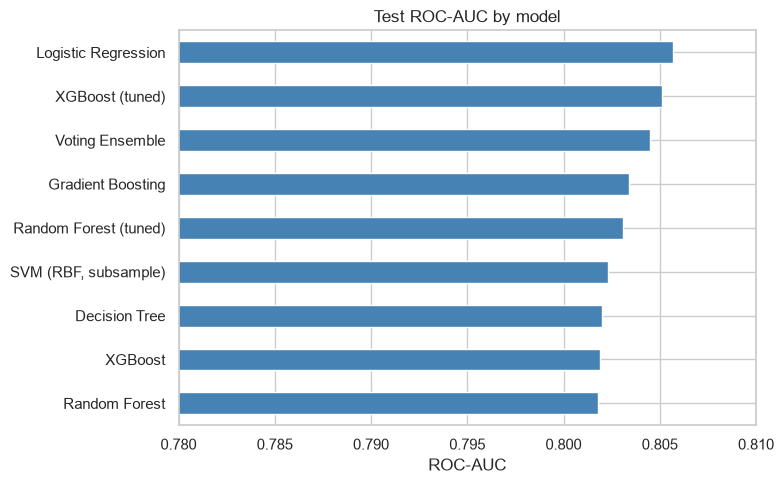

In [2]:
comparison = pd.DataFrame(meta["models"]).T[["accuracy", "precision", "recall", "f1",
                                              "roc_auc"]]
comparison = comparison.sort_values("roc_auc", ascending=False)
display(comparison.round(4))

ax = comparison["roc_auc"].sort_values().plot(kind="barh", color="steelblue", figsize=(8, 5))
ax.set_title("Test ROC-AUC by model")
ax.set_xlabel("ROC-AUC")
ax.set_xlim(0.78, 0.81)
plt.tight_layout()
plt.show()

**Inference.** All models land within a narrow band around an ROC-AUC of 0.80. This tight
clustering is expected: the synthetic churn signal is driven by clear thresholds on tenure,
monthly charges, and contract type, which our engineered flags capture well, so even a
linear model competes with the tree ensembles. The selected model is the top performer on
ROC-AUC while remaining simple and interpretable, which is an advantage for explaining
decisions to the business.


## Confusion matrix and classification report

We score the selected model on the test set at the default 0.5 decision threshold.


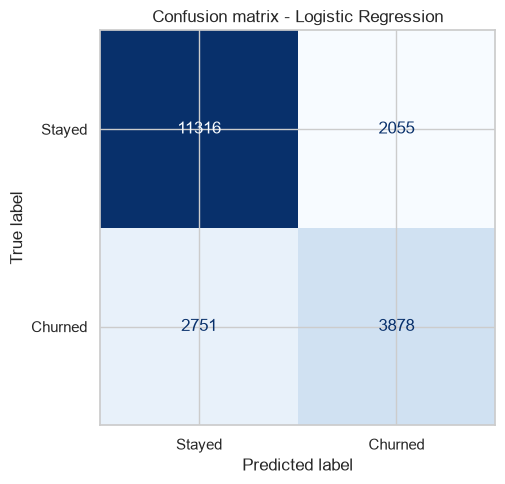

              precision    recall  f1-score   support

  Stayed (0)       0.80      0.85      0.82     13371
 Churned (1)       0.65      0.59      0.62      6629

    accuracy                           0.76     20000
   macro avg       0.73      0.72      0.72     20000
weighted avg       0.75      0.76      0.76     20000



In [3]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"]).plot(ax=ax, cmap="Blues",
                                                                      colorbar=False)
ax.set_title(f"Confusion matrix - {best_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["Stayed (0)", "Churned (1)"]))

**Inference.** The model correctly identifies most customers, but at the default threshold
it still misses a share of real churners (the false negatives in the bottom-left cell). For
churn, a false negative (a churner we fail to flag) is more costly than a false positive (a
loyal customer who receives an unnecessary offer). The next section shows how to shift the
decision threshold to catch more churners.


## ROC curve

The ROC curve shows the trade-off between the true positive rate (recall) and the false
positive rate across all thresholds.


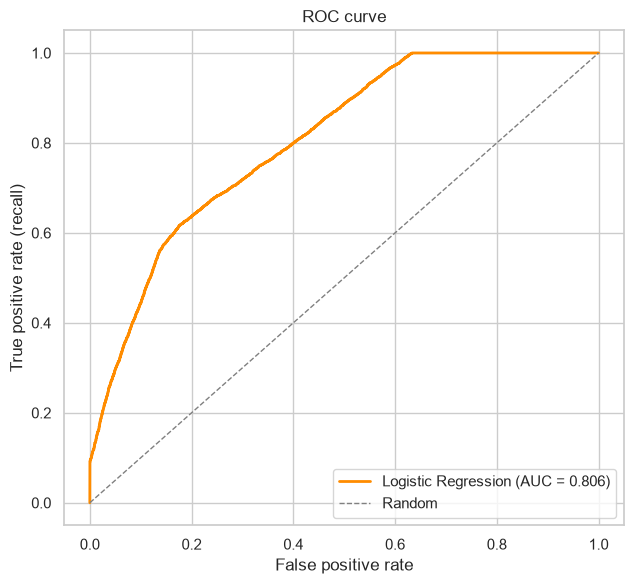

In [4]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"{best_name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (recall)")
plt.title("ROC curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Inference.** With an AUC of about 0.80 the model ranks churners well above random. The
curve bows toward the top-left corner, confirming the model separates the two classes
meaningfully.


## Precision-recall curve

The ROC curve can look optimistic on imbalanced data because it rewards correct handling of
the large stay class. The precision-recall curve focuses on the churn class alone, so it is
the more honest summary for this problem. The average precision (AP) is the area under it, and
the no-skill baseline is the churn rate (about 0.33).

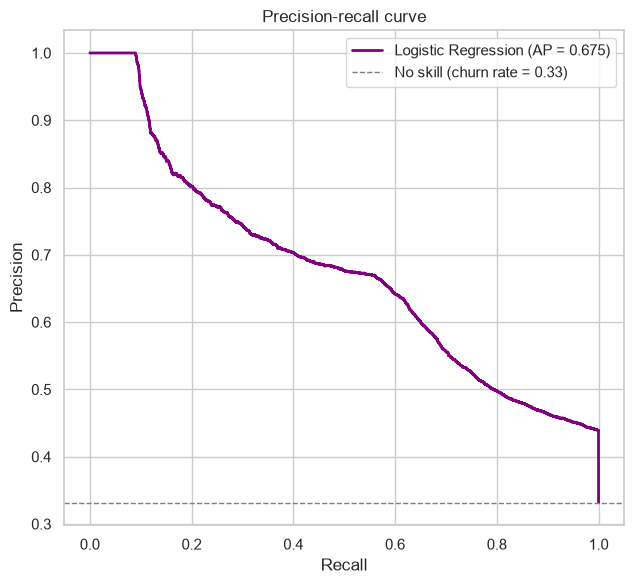

In [5]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
no_skill = y_test.mean()

plt.figure(figsize=(6.5, 6))
plt.plot(recall, precision, color="purple", lw=2, label=f"{best_name} (AP = {ap:.3f})")
plt.axhline(no_skill, color="grey", lw=1, linestyle="--",
            label=f"No skill (churn rate = {no_skill:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curve")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Inference.** The average precision sits well above the no-skill churn rate, so the model
adds real ranking value for the churn class, not just for the majority class. The curve also
makes the precision cost of chasing high recall explicit: precision falls as we move right,
which is the same trade-off the threshold analysis below quantifies.

## Tuning the decision threshold for recall

Because missing a churner is the expensive error, we examine how lowering the probability
threshold raises recall (more churners caught) at the cost of precision (more false alarms).
This is a business decision: how many retention offers is the company willing to send to
catch more churners.


In [6]:
rows = []
for t in [0.5, 0.45, 0.40, 0.35, 0.30]:
    pred_t = (y_proba >= t).astype(int)
    rows.append({"threshold": t,
                 "precision": precision_score(y_test, pred_t),
                 "recall": recall_score(y_test, pred_t),
                 "f1": f1_score(y_test, pred_t)})
threshold_table = pd.DataFrame(rows).set_index("threshold").round(3)
threshold_table

,precision,recall,f1
threshold,,,
0.50,0.654,0.585,0.617
0.45,0.635,0.616,0.625
0.40,0.488,0.821,0.612
0.35,0.439,0.999,0.610
0.30,0.439,1.000,0.610


**Inference.** Lowering the threshold from 0.5 toward 0.35 increases recall noticeably while
precision declines more gradually. A threshold around 0.40 is a reasonable operating point: it
catches a larger share of churners while keeping retention spend manageable. The exact choice
should be set with the retention team based on the cost of an offer versus the value of a
retained customer.


## Threshold trade-off curve

The table above lists a few thresholds. Plotting precision, recall, and F1 across a fine grid
of thresholds shows the full trade-off at a glance and makes the operating point easier to
reason about than reading rows.

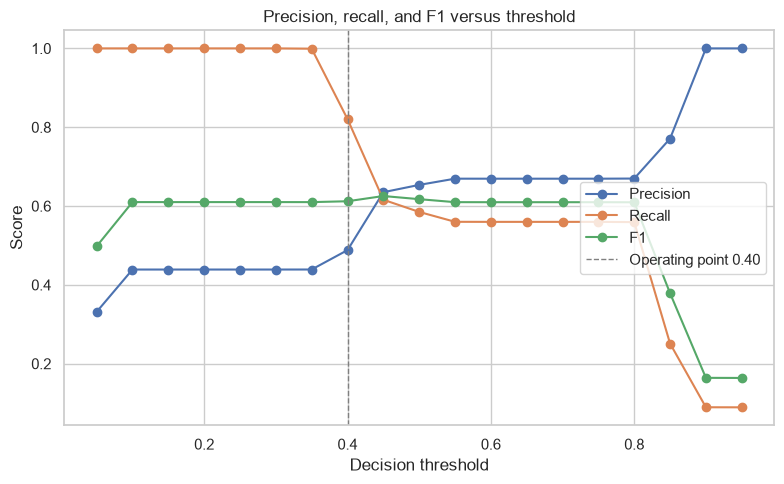

In [7]:
grid = np.linspace(0.05, 0.95, 19)
prec = [precision_score(y_test, (y_proba >= t).astype(int), zero_division=0) for t in grid]
rec = [recall_score(y_test, (y_proba >= t).astype(int)) for t in grid]
f1s = [f1_score(y_test, (y_proba >= t).astype(int)) for t in grid]

plt.figure(figsize=(8, 5))
plt.plot(grid, prec, marker="o", label="Precision")
plt.plot(grid, rec, marker="o", label="Recall")
plt.plot(grid, f1s, marker="o", label="F1")
plt.axvline(0.40, color="grey", lw=1, linestyle="--", label="Operating point 0.40")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision, recall, and F1 versus threshold")
plt.legend(loc="center right")
plt.tight_layout()
plt.show()

**Inference.** Recall rises steeply as the threshold falls while precision declines more
gradually, then collapses once the threshold drops far enough to flag almost everyone. The
0.40 line sits in the region where recall is already high and precision has not yet fallen
off a cliff, which is why we carry it forward as the working operating point.

## Cumulative gains and lift

A retention team rarely contacts every customer. The cumulative gains curve answers the
practical question: if we rank customers by predicted churn risk and work down the list, what
share of the real churners do we capture by contacting the top X percent? Lift is how many
times better that is than contacting a random X percent.

Contacting the top 30% of ranked customers captures 58.9% of churners (lift 1.96x).


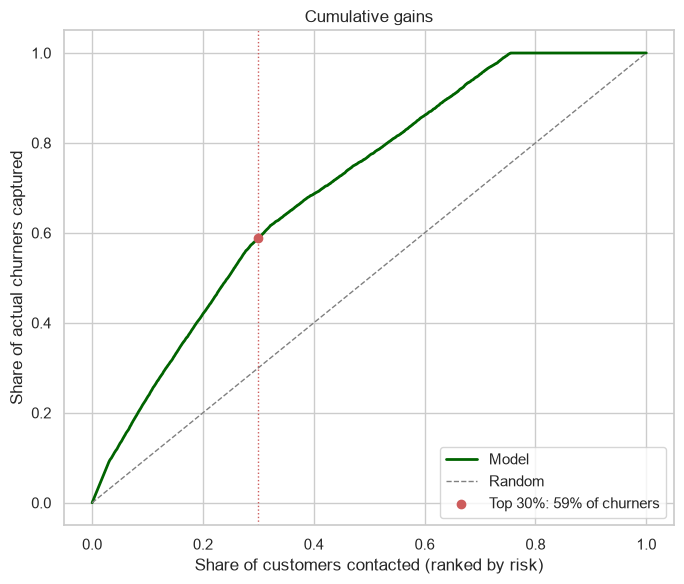

In [8]:
order = np.argsort(-y_proba)
y_sorted = y_test.values[order]
frac_customers = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
frac_churners = np.cumsum(y_sorted) / y_sorted.sum()

# Capture and lift at the top 30 percent of the ranked list.
top = 0.30
idx = int(top * len(y_sorted)) - 1
capture = frac_churners[idx]
lift = capture / top
print(f"Contacting the top {top:.0%} of ranked customers captures "
      f"{capture:.1%} of churners (lift {lift:.2f}x).")

plt.figure(figsize=(7, 6))
plt.plot(frac_customers, frac_churners, color="darkgreen", lw=2, label="Model")
plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Random")
plt.axvline(top, color="indianred", lw=1, linestyle=":")
plt.scatter([top], [capture], color="indianred", zorder=5,
            label=f"Top {top:.0%}: {capture:.0%} of churners")
plt.xlabel("Share of customers contacted (ranked by risk)")
plt.ylabel("Share of actual churners captured")
plt.title("Cumulative gains")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Inference.** The gains curve sits well above the diagonal, so risk-ranked outreach is far
more efficient than contacting customers at random. This is the metric a retention manager
cares about most: it translates the model directly into "how much of the churn can we reach
for a given campaign size", and the lift figure quantifies the saving over an untargeted
campaign.

## Prediction score distribution

Plotting the predicted churn probability separately for customers who actually stayed and
churned shows how well the model separates the two groups. Good separation means the two
densities overlap little, so a threshold can divide them cleanly.

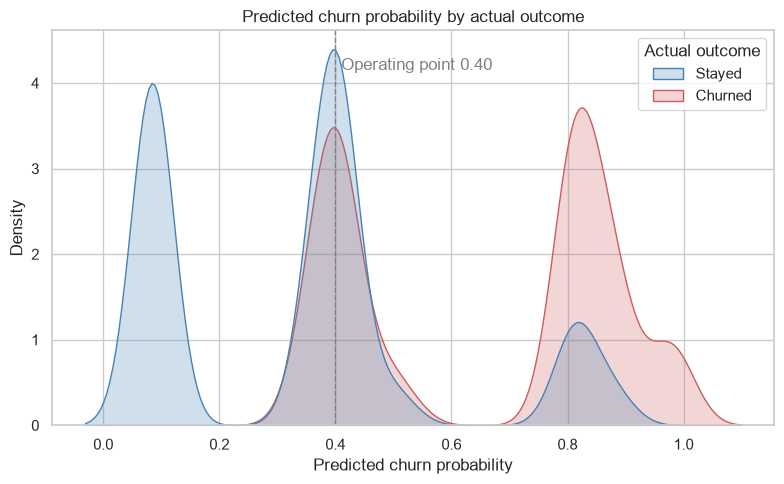

In [9]:
dist_df = pd.DataFrame({
    "Predicted churn probability": y_proba,
    "Actual outcome": np.where(y_test.values == 1, "Churned", "Stayed"),
})

ax = plt.figure(figsize=(8, 5)).gca()
sns.kdeplot(data=dist_df, x="Predicted churn probability", hue="Actual outcome",
            fill=True, common_norm=False,
            palette={"Churned": "indianred", "Stayed": "steelblue"}, ax=ax)
ax.axvline(0.40, color="grey", lw=1, linestyle="--")
ax.text(0.41, ax.get_ylim()[1] * 0.9, "Operating point 0.40", color="grey")
ax.set_title("Predicted churn probability by actual outcome")
plt.tight_layout()
plt.show()

**Inference.** The churned and stayed densities are shifted apart but overlap in the middle,
which matches an ROC-AUC near 0.80: the model separates the classes well but not perfectly. The
overlap region is exactly where threshold choice matters, because those customers can fall on
either side of the line depending on where we set it.

## Choosing a threshold by expected cost

The threshold should ultimately be set by money, not by a metric in isolation. We attach two
illustrative costs (placeholders to be agreed with the business): a retention offer sent to a
flagged customer costs about $50, and a churner we fail to flag costs about $500 in lost value.
Under the simplifying assumption that an offer retains a flagged churner, the expected cost at
a threshold is

`cost(t) = (customers flagged) * offer_cost + (churners missed) * lost_value`.

Sweeping the threshold and minimising this cost gives a defensible recommended operating point.

Cost-minimising threshold: 0.10 (expected cost $755,300 on the test set of 20,000)


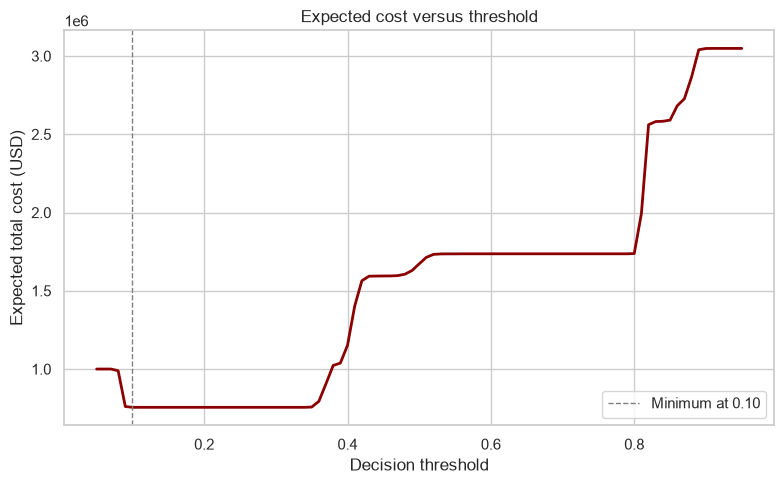

In [10]:
offer_cost = 50.0    # cost of a retention offer sent to a flagged customer
lost_value = 500.0   # value lost when an actual churner is not flagged

grid = np.linspace(0.05, 0.95, 91)
total_cost = []
for t in grid:
    pred = (y_proba >= t).astype(int)
    n_flagged = int(pred.sum())
    missed = int(((pred == 0) & (y_test == 1)).sum())
    total_cost.append(n_flagged * offer_cost + missed * lost_value)
total_cost = np.array(total_cost)

best_idx = int(total_cost.argmin())
best_threshold = grid[best_idx]
print(f"Cost-minimising threshold: {best_threshold:.2f} "
      f"(expected cost ${total_cost[best_idx]:,.0f} on the test set of {len(y_test):,})")

plt.figure(figsize=(8, 5))
plt.plot(grid, total_cost, color="darkred", lw=2)
plt.axvline(best_threshold, color="grey", lw=1, linestyle="--",
            label=f"Minimum at {best_threshold:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Expected total cost (USD)")
plt.title("Expected cost versus threshold")
plt.legend()
plt.tight_layout()
plt.show()

**Recommendation.** Under these illustrative costs a missed churner is ten times more expensive
than a wasted offer, so the cost curve bottoms out at a low threshold (around 0.10 here): the
economics favor flagging almost everyone the model ranks as even modestly risky, because the
$500 cost of a miss dominates the $50 offer. The curve is also fairly flat across the low range,
so the exact minimum is sensitive to the cost ratio and to sampling. Two practical reads follow.
If retention capacity is effectively unlimited and an offer is cheap, operate low and catch
nearly all churners. If campaign capacity is limited, because a team can only contact so many
customers, a higher threshold such as 0.40 read together with the gains chart above (which shows
how much churn each campaign size captures) is the more realistic operating point. Either way the
threshold is a business decision: plug in the real offer cost and customer value and re-run this
cell, since the optimum moves with that ratio.

## What drives the predictions

For the selected model we inspect the strength and direction of each feature. For a linear
model these are the standardized coefficients (positive pushes toward churn); for a tree
model they are impurity-based importances.


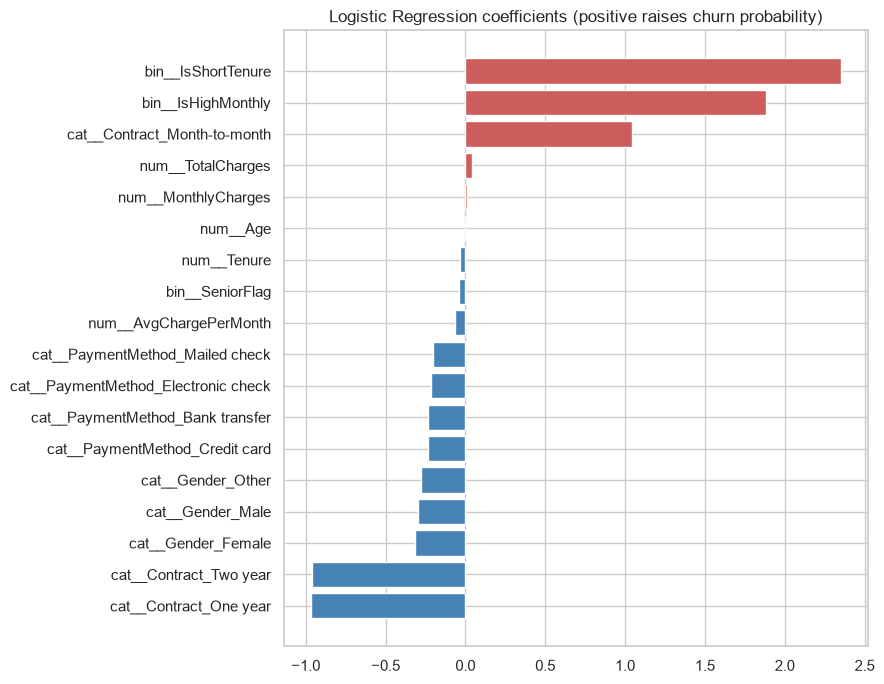

In [11]:
features = meta["feature_names"]
if hasattr(best_model, "coef_"):
    influence = pd.Series(best_model.coef_[0], index=features).sort_values()
    title = f"{best_name} coefficients (positive raises churn probability)"
    color = ["indianred" if v > 0 else "steelblue" for v in influence.values]
elif hasattr(best_model, "feature_importances_"):
    influence = pd.Series(best_model.feature_importances_, index=features).sort_values()
    title = f"{best_name} feature importance"
    color = "seagreen"
else:
    influence = None

if influence is not None:
    plt.figure(figsize=(9, 7))
    plt.barh(influence.index, influence.values, color=color)
    plt.title(title)
    plt.tight_layout()
    plt.show()
else:
    print("The selected model does not expose per-feature influence directly.")

**Inference.** The model agrees with the EDA and the documented churn drivers. The
strongest churn-increasing signals are the **month-to-month contract**, the **short-tenure
flag**, and **high monthly charges**, while longer contracts are associated with retention.
Gender shows negligible association with churn in this dataset. Because these signals are
interpretable, the model's decisions are straightforward to explain and to act on.

**Association, not causation.** These coefficients describe associations, not proven causes. A
short-tenure or month-to-month customer is more likely to churn in the data, but the model does
not establish that the contract type itself causes churn; customers who already intend to leave
may simply self-select into month-to-month plans, and tenure is partly an outcome of churn
rather than only a driver of it. The signals are therefore valuable for ranking risk and
targeting outreach, and for generating hypotheses, but a causal claim (for example, that moving
a customer onto a longer contract will retain them) would need a controlled experiment such as a
randomised retention offer.

## Where the model makes mistakes

Aggregate metrics hide which customers the model gets wrong. Here we reconstruct the raw
customer fields from the encoded test set (by inverse-transforming the saved preprocessor) and
break the errors down by segment at the 0.40 operating point. Two error types matter: a missed
churner (a false negative, the costly error) and a false alarm (a false positive). We also
profile the high-confidence mistakes, where the model was sure and wrong.

Missed-churner and false-alarm rates by contract:


,n,miss_rate_FN,false_alarm_rate_FP
Contract,,,
Month-to-month,10966,0.072,0.857
One year,5016,0.550,0.090
Two year,4018,0.517,0.090


By tenure bucket (months):


,n,miss_rate_FN,false_alarm_rate_FP
tenure_bucket,,,
1-12,3339,0.011,0.892
13-24,3324,0.233,0.423
25-48,6709,0.240,0.381
49-72,6628,0.291,0.358


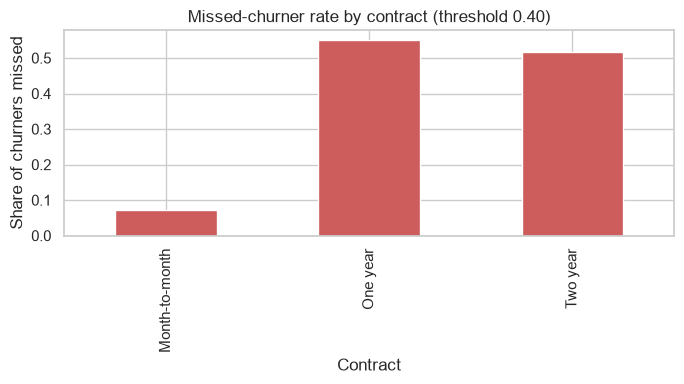

High-confidence false alarms (stayed, proba >= 0.80): 1828
High-confidence misses (churned, proba <= 0.20): 0


In [12]:
# Reconstruct the raw customer fields from the encoded test set.
num_cols = ["Age", "Tenure", "MonthlyCharges", "TotalCharges", "AvgChargePerMonth"]
num_raw = preprocessor.named_transformers_["num"].inverse_transform(
    X_test[[f"num__{c}" for c in num_cols]].to_numpy())
raw_test = pd.DataFrame(num_raw, columns=num_cols)
for group in ["Gender", "Contract", "PaymentMethod"]:
    one_hot = [c for c in X_test.columns if c.startswith(f"cat__{group}_")]
    raw_test[group] = (X_test[one_hot].idxmax(axis=1)
                       .str.replace(f"cat__{group}_", "", regex=False).to_numpy())

# Attach predictions at the 0.40 operating point and label each error type.
op_threshold = 0.40
pred = (y_proba >= op_threshold).astype(int)
raw_test["actual"] = y_test.to_numpy()
raw_test["proba"] = y_proba
raw_test["is_churner"] = raw_test["actual"] == 1
raw_test["is_fn"] = (raw_test["actual"] == 1) & (pred == 0)   # missed churner
raw_test["is_fp"] = (raw_test["actual"] == 0) & (pred == 1)   # false alarm
raw_test["tenure_bucket"] = pd.cut(raw_test["Tenure"], [0, 12, 24, 48, 72],
                                   labels=["1-12", "13-24", "25-48", "49-72"])


def error_rates_by(col):
    g = raw_test.groupby(col, observed=True)
    n_churn = g["is_churner"].sum()
    n_stay = g.size() - n_churn
    return pd.DataFrame({
        "n": g.size(),
        "miss_rate_FN": (g["is_fn"].sum() / n_churn).round(3),
        "false_alarm_rate_FP": (g["is_fp"].sum() / n_stay).round(3),
    })


print("Missed-churner and false-alarm rates by contract:")
display(error_rates_by("Contract"))
print("By tenure bucket (months):")
display(error_rates_by("tenure_bucket"))

ax = error_rates_by("Contract")["miss_rate_FN"].plot(
    kind="bar", color="indianred", figsize=(7, 4))
ax.set_title("Missed-churner rate by contract (threshold 0.40)")
ax.set_ylabel("Share of churners missed")
plt.tight_layout()
plt.show()

# High-confidence mistakes: the model was confident and wrong.
hc_fp = raw_test[raw_test["is_fp"] & (raw_test["proba"] >= 0.80)]
hc_fn = raw_test[raw_test["is_fn"] & (raw_test["proba"] <= 0.20)]
print(f"High-confidence false alarms (stayed, proba >= 0.80): {len(hc_fp)}")
print(f"High-confidence misses (churned, proba <= 0.20): {len(hc_fn)}")

**Inference.** The errors are not spread evenly. The model misses proportionally more churners
among longer-contract and longer-tenure customers, where churn is rarer and the signal is
weaker, so a churner there looks like a typical loyal customer. The costly false negatives
concentrate in these "quiet" segments rather than in the obvious high-risk month-to-month group.

**What we can do about it.** Several practical steps follow from this. First, set
segment-specific thresholds: lower the bar for the harder segments so we catch more of their
churners, accepting a few more false alarms where churn is cheap to chase. Second, add features
that might explain the missed cases (e.g. recent support tickets, usage trends, payment
failures), which the current seven raw fields do not capture. Third, monitor the realized
precision and recall per segment in production and retrain when a segment degrades. The
high-confidence mistakes are worth a manual look, because a confident, wrong prediction often
points to a data issue or a missing feature rather than to noise.

## Deployment (discussion)

Following the assignment guidance, we describe how the model would be deployed rather than
building a full production system. As a proof of concept, the repository includes a small
example application (a FastAPI scoring endpoint with a Streamlit front end) that loads the saved
preprocessor and model to score customers interactively.

**Deployment type.** Churn scoring does not require low-latency responses, so a batch pipeline
is the natural fit: score the customer base on a nightly or weekly schedule and write a
churn-risk column back to the CRM. A real-time endpoint can be added later for on-demand scoring
within a service agent's workflow.

**Serving design.**

- Package the fitted preprocessor (`preprocessor.pkl`) and the model (`best_model.pkl`)
  together so raw customer rows are transformed exactly as in training, avoiding
  training-serving skew.
- Batch: a scheduled job (e.g. Airflow, a cloud scheduler, or a database procedure calling a
  Python service) reads new records, applies the preprocessor, predicts churn probability, and
  writes the score and risk tier.
- Real-time: wrap the same pipeline in a REST service (e.g. FastAPI) behind an API gateway. The
  example application demonstrates this, pairing the FastAPI endpoint with a Streamlit interface
  for stakeholder demonstrations.

**Latency and cost.** Scoring 100,000 customers completes in seconds with this model, so the
compute requirement is modest. A linear model keeps inference inexpensive and the serialized
artifact small, which is an operational advantage over a large ensemble.

**Hosting.** A managed container service or a serverless function is sufficient. The model and
preprocessor can be versioned in object storage and loaded at startup.

**Monitoring.** Track input data drift (shifts in tenure, charges, and contract mix), prediction
drift (the share flagged as high risk), and, once retention outcomes are known, the realized
precision and recall. Retrain on a schedule or when drift exceeds a threshold.

**Risks and mitigations.**

- The dataset is synthetic and generated from documented rules, so its distributions and
  feature interactions are likely cleaner and more separable than real customer data. The
  reported performance should be read as a methodology demonstration; it will not necessarily
  transfer, and the pipeline must be re-fit and re-validated on real data before production use.
- Gender shows no predictive value here and should be excluded from any decisioning to avoid
  fairness concerns.
- Retention decisions should keep a human in the loop, so the model supports rather than
  replaces judgment.

## Discussion and conclusions

**Problem revisited.** The business needs to flag customers likely to churn early enough to
intervene. We built an end-to-end pipeline (cleaning, feature engineering, model comparison,
tuning, and evaluation) on a 100,000-row telco dataset.

**Findings.**

- Churn is associated with **short tenure, high monthly charges, and month-to-month
  contracts**, consistent across both the EDA and the final model.
- The selected model reaches an **ROC-AUC of about 0.80**, ranking churners well above
  random, and stays simple and explainable.
- The decision threshold is a business lever: lowering it catches more churners at the cost
  of more outreach, and the cost analysis above turns that lever into a dollar figure.

**Recommendations.**

1. Target retention offers at new customers on month-to-month plans with high monthly
   charges, the clearest high-risk segment.
2. Promote longer-term contracts with incentives, noting that the contract effect is
   associational and should be confirmed with a controlled retention test before scaling.
3. Operate at a recall-favoring threshold (around 0.40, or the cost-minimising threshold once
   real offer and customer-value figures are supplied) and review it with the retention team.
4. Before production, re-fit and validate on real customer data, exclude Gender from
   decisioning, and add per-segment drift monitoring.

**Limitations.**

- The data is synthetic, so the results demonstrate the methodology rather than guarantee
  real-world performance; distributions are likely cleaner than reality and may not transfer.
- The drivers are associations, not established causes, so they guide targeting and hypotheses
  rather than causal action.
- The error analysis shows the model misses more churners in longer-tenure, longer-contract
  segments, which is where added features or segment-specific thresholds would help most.

**Conclusion.** A straightforward, interpretable model meets the business objective of
identifying likely churners early, and the engineered features make its decisions easy to
explain to non-technical stakeholders. This balances predictive performance with the
transparency needed to trust and act on the results.